## Load the Normalized Data

In [1]:
import pandas as pd 
import numpy as np 

data = pd.read_csv('../data/processed/normalized_data.csv') 
data.set_index('Date', inplace=True)
data.index = pd.to_datetime(data.index)

print('Data shape:', data.shape)
print('Data columns:', data.columns.tolist())
print(data.head())

Data shape: (3653, 5)
Data columns: ['Close', 'High', 'Low', 'Open', 'Volume']
               Close      High       Low      Open    Volume
Date                                                        
2016-05-30 -1.003578 -1.006435 -0.999605 -1.003219 -1.141907
2016-05-31 -1.003653 -1.006367 -0.999676 -1.003044 -1.139685
2016-06-01 -1.003484 -1.006473 -0.999522 -1.003138 -1.141990
2016-06-02 -1.003452 -1.006555 -0.999290 -1.002973 -1.143120
2016-06-03 -1.002498 -1.005524 -0.999171 -1.002937 -1.140408


## Create the EMA (Exponential Moving Average)

In [2]:

def calculate_ema(prices, span):
    """
    calculate Exponential Moving Average
    span: number of days to calculate the EMA(e.g. 12, 26)
    """

    return prices.ewm(span=span, adjust=False).mean()

# Calculate EMA for different period
data['EMA_12'] = calculate_ema(data['Close'], 12)
data['EMA_26'] = calculate_ema(data['Close'], 26)
data['EMA_50'] = calculate_ema(data['Close'], 50)

data['EMA_Signal'] = data['EMA_12'] - data['EMA_26']
data['Price_to_EMA12'] = data['Close'] / data['EMA_12']
data['Price_to_EMA26'] = data['Close'] / data['EMA_26']
data['Price_to_EMA50'] = data['Close'] / data['EMA_50']

print('EMA features created')
print(data[['Close', 'EMA_12', 'EMA_26', 'EMA_50', 'EMA_Signal', 'Price_to_EMA12', 'Price_to_EMA26', 'Price_to_EMA50']].head())


EMA features created
               Close    EMA_12    EMA_26    EMA_50  EMA_Signal  \
Date                                                             
2016-05-30 -1.003578 -1.003578 -1.003578 -1.003578    0.000000   
2016-05-31 -1.003653 -1.003589 -1.003583 -1.003581   -0.000006   
2016-06-01 -1.003484 -1.003573 -1.003576 -1.003577    0.000003   
2016-06-02 -1.003452 -1.003555 -1.003567 -1.003572    0.000012   
2016-06-03 -1.002498 -1.003392 -1.003488 -1.003530    0.000096   

            Price_to_EMA12  Price_to_EMA26  Price_to_EMA50  
Date                                                        
2016-05-30        1.000000        1.000000        1.000000  
2016-05-31        1.000064        1.000070        1.000072  
2016-06-01        0.999911        0.999909        0.999908  
2016-06-02        0.999898        0.999886        0.999881  
2016-06-03        0.999109        0.999014        0.998972  


### Plot a graph to display how the different EMA varies with time based on the normalized data

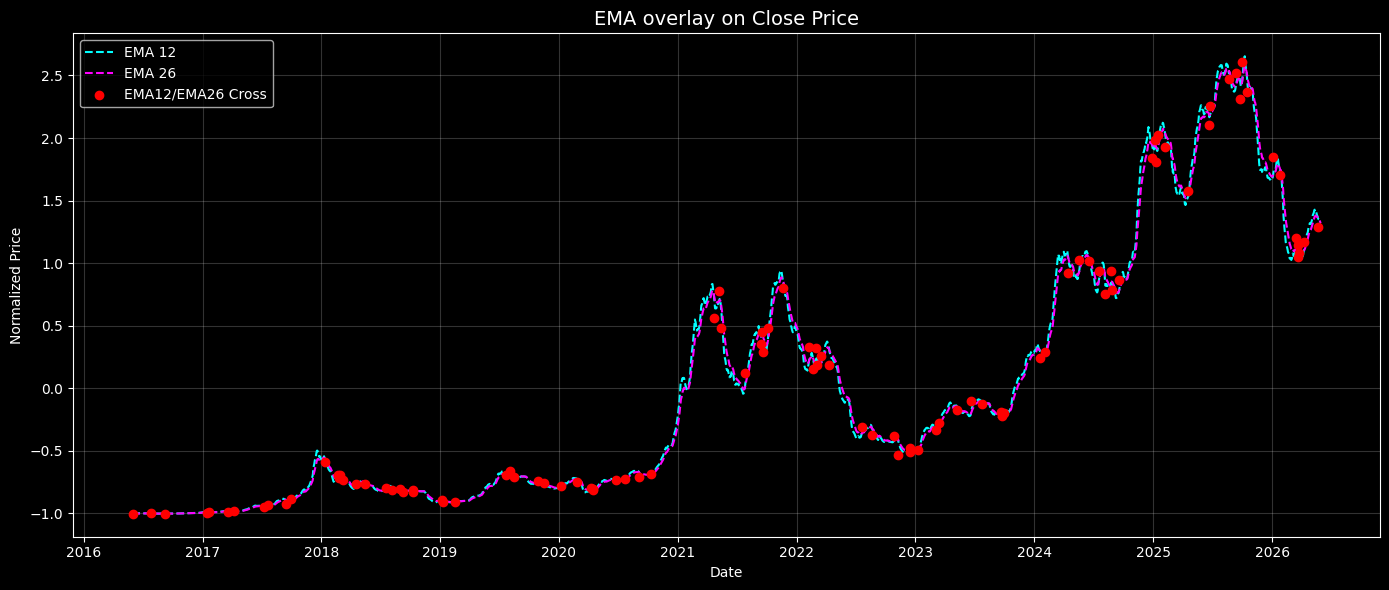

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure datetime index
if not pd.api.types.is_datetime64_any_dtype(data.index):
    data = data.copy()
    data.index = pd.to_datetime(data.index, errors='coerce')
    data = data[~data.index.isna()]

plt.style.use('dark_background')
plt.figure(figsize=(14,6))

# Close price and EMAs
#plt.plot(data.index, data['Close'], label='Close', color='white', linewidth=1.8)
plt.plot(data.index, data['EMA_12'], label='EMA 12', color='cyan', linestyle='--', linewidth=1.5)
plt.plot(data.index, data['EMA_26'], label='EMA 26', color='magenta', linestyle='--', linewidth=1.5)

# EMA12/EMA26 cross points (sign change)
cross_points = data[data['EMA_Signal'] * data['EMA_Signal'].shift(1) < 0]
plt.scatter(cross_points.index, cross_points['Close'], color='red', label='EMA12/EMA26 Cross', zorder=30)

plt.title('EMA overlay on Close Price', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


## Create RSI(Relative Strength Index)

In [4]:
def calculate_rsi(prices, window=14):
    """
    Calculate the RSI
    window: number of days to calculate the RSI(e.g. 14)
    """

    #price change
    delta  = prices.diff()

    #gain and loss
    gain = delta.where(delta > 0, 0)
    loss = delta.where(delta < 0, 0)

    #average gain and loss using EMA
    avg_gain = gain.ewm(span=window, adjust=False).mean()
    avg_loss = loss.ewm(span=window, adjust=False).mean()

    #Calculate RS
    rs = avg_gain / -avg_loss.replace(0, 1e-10)

    #Calculate RSI
    rsi = 100 - (100 / (1 + rs))

    return rsi

#Create RSI features
data['RSI_14'] = calculate_rsi(data['Close'], 14)
data['RSI_7'] = calculate_rsi(data['Close'], 7)

#RSI-based features
data['RSI_Overbought'] = (data['RSI_14'] > 70).astype(int) # if overbought, 0 otherwise
data['RSI_Oversold'] = (data['RSI_14'] < 30).astype(int) # if oversold, 0 otherwise
data['RSI_Neutral'] = ((data['RSI_14'] >= 30) & (data['RSI_14'] <= 70)).astype(int) # if neutral, 1 otherwise

print('RSI features created')
print(data[['Close', 'RSI_14', 'RSI_7', 'RSI_Overbought', 'RSI_Oversold', 'RSI_Neutral']].head(20))



RSI features created
               Close     RSI_14      RSI_7  RSI_Overbought  RSI_Oversold  \
Date                                                                       
2016-05-30 -1.003578   0.000000   0.000000               0             1   
2016-05-31 -1.003653   0.000000   0.000000               0             1   
2016-06-01 -1.003484  72.042048  74.859436               1             0   
2016-06-02 -1.003452  75.857105  78.868890               1             0   
2016-06-03 -1.002498  95.744179  97.109653               1             0   
2016-06-04 -1.002390  96.157449  97.442714               1             0   
2016-06-05 -1.002322  96.413379  97.670636               1             0   
2016-06-06 -1.001999  97.364111  98.504646               1             0   
2016-06-07 -1.002272  77.338351  70.152323               1             0   
2016-06-08 -1.002118  80.016280  75.468299               1             0   
2016-06-09 -1.002332  67.270008  56.742967               0         

### Plot a graph to display how the different RSI signal variation with time based on the normalized data

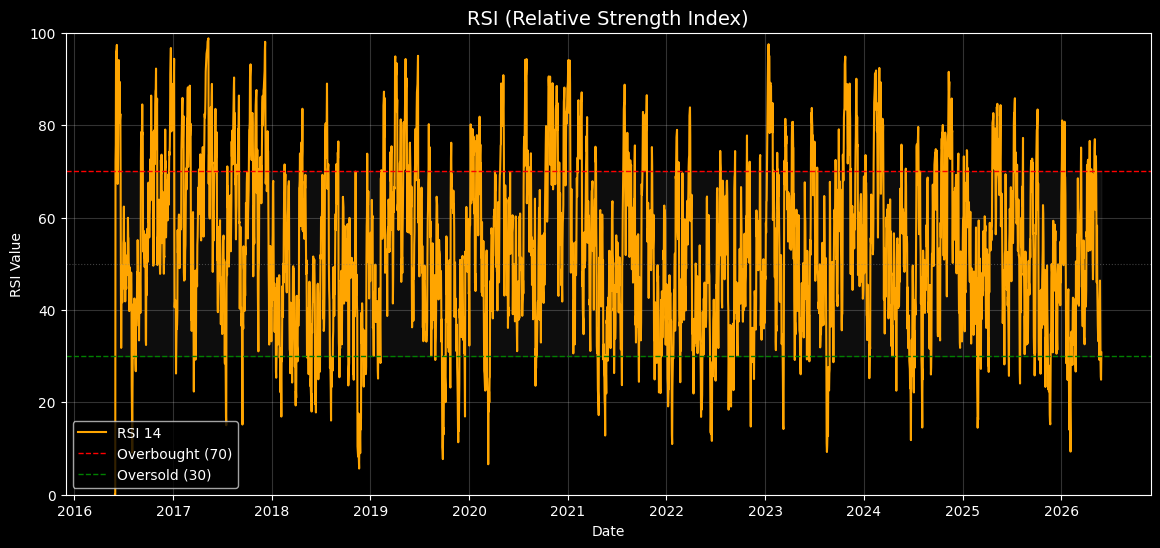

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

if not pd.api.types.is_datetime64_any_dtype(data.index):
   data = data.copy()
   data.index = pd.to_datetime(data.index, errors='coerce')
   data = data[~data.index.isna()]

plt.style.use('dark_background')
plt.figure(figsize=(14, 6))

plt.plot(data.index, data['RSI_14'], label='RSI 14', color='orange', linewidth=1.5)
plt.axhline(y=70, color='red', linestyle='--', linewidth=1, label='Overbought (70)')
plt.axhline(y=30, color='green', linestyle='--', linewidth=1, label='Oversold (30)')
plt.axhline(y=50, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
plt.fill_between(data.index, 30, 70, alpha=0.1, color='gray')
plt.ylabel('RSI Value')
plt.xlabel('Date')
plt.title('RSI (Relative Strength Index)', fontsize=14)
plt.ylim(0, 100)
plt.legend()
plt.grid(True, alpha=0.2)

## Create the Volatility Features

Volatility is mathematically computed on raw Close prices (since log-returns of negative normalized z-scores are undefined). We calculate the 14-day and 30-day rolling standard deviations of daily log returns and then normalize them using a standard scaler to match the continuous scaling of the other features.

In [6]:
from sklearn.preprocessing import StandardScaler

# Load raw price data to calculate true returns and rolling volatility
raw_data = pd.read_csv('../data/processed/yahooFinanceDataCleaned.csv')
raw_data.set_index('Date', inplace=True)
raw_data.index = pd.to_datetime(raw_data.index)

# Align dates with our existing normalized data
raw_close = raw_data.loc[data.index, 'Close']

# Calculate daily log returns
log_returns = np.log(raw_close / raw_close.shift(1))

# Compute rolling standard deviations of daily returns
volatility_14 = log_returns.rolling(window=14).std()
volatility_30 = log_returns.rolling(window=30).std()

# Scale the new volatility features using z-score standardization
scaler = StandardScaler()

# fit_transform expects a 2D array, so we reshape and handle NaNs after/during the transform
# We fill NaNs at the beginning with 0 (representing the mean of standardized volatility)
vol_14_scaled = scaler.fit_transform(volatility_14.fillna(volatility_14.mean()).values.reshape(-1, 1)).flatten()
vol_30_scaled = scaler.fit_transform(volatility_30.fillna(volatility_30.mean()).values.reshape(-1, 1)).flatten()

data['Volatility_14'] = vol_14_scaled
data['Volatility_30'] = vol_30_scaled

print('Volatility features created and standardized successfully!')
print(data[['Close', 'Volatility_14', 'Volatility_30']].head(20))

Volatility features created and standardized successfully!
               Close  Volatility_14  Volatility_30
Date                                              
2016-05-30 -1.003578   2.059300e-16            0.0
2016-05-31 -1.003653   2.059300e-16            0.0
2016-06-01 -1.003484   2.059300e-16            0.0
2016-06-02 -1.003452   2.059300e-16            0.0
2016-06-03 -1.002498   2.059300e-16            0.0
2016-06-04 -1.002390   2.059300e-16            0.0
2016-06-05 -1.002322   2.059300e-16            0.0
2016-06-06 -1.001999   2.059300e-16            0.0
2016-06-07 -1.002272   2.059300e-16            0.0
2016-06-08 -1.002118   2.059300e-16            0.0
2016-06-09 -1.002332   2.059300e-16            0.0
2016-06-10 -1.002246   2.059300e-16            0.0
2016-06-11 -1.001352   2.059300e-16            0.0
2016-06-12 -0.999334   2.059300e-16            0.0
2016-06-13 -0.998369   1.012842e-01            0.0
2016-06-14 -0.998944   2.074444e-01            0.0
2016-06-15 -0.998672   

### Plot rolling Volatility over time

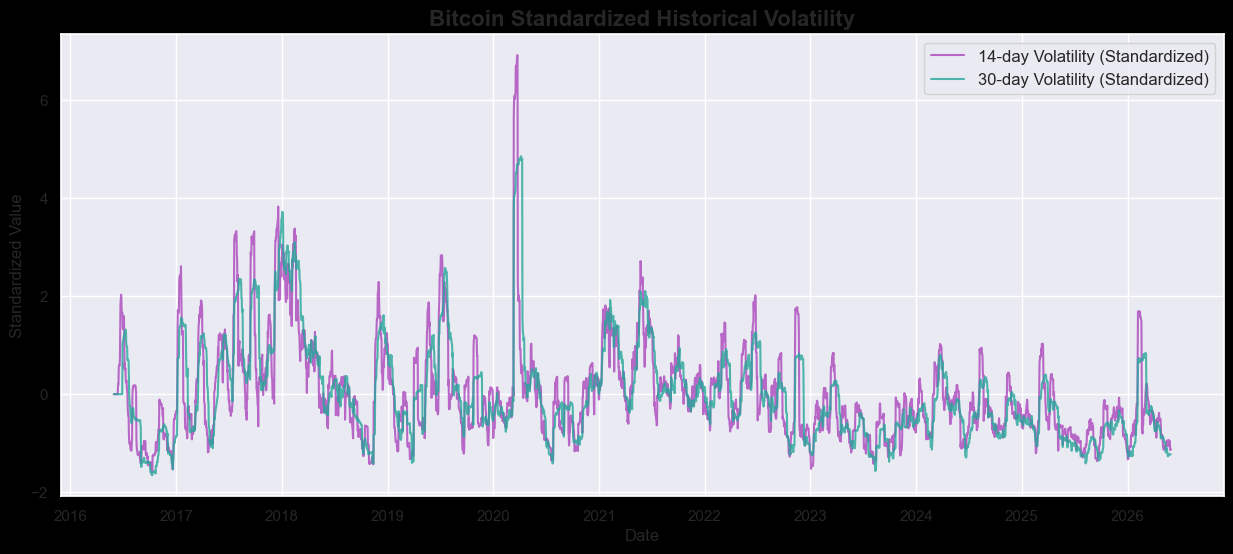

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))
sns.set_theme(style="darkgrid")

plt.plot(data.index, data['Volatility_14'], label='14-day Volatility (Standardized)', color='#ab47bc', alpha=0.8)
plt.plot(data.index, data['Volatility_30'], label='30-day Volatility (Standardized)', color='#26a69a', alpha=0.8)

plt.title('Bitcoin Standardized Historical Volatility', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Standardized Value', fontsize=12)
plt.legend(fontsize=12)

# Save the volatility trend plot to processed directory
plt.savefig('../data/processed/btc_volatility_trend.png', dpi=300, bbox_inches='tight')
plt.show()

## Combine Engineered Features and Export Dataset

We compile a final consolidated dataset containing all our engineered technical indicators (EMA crossovers, price-to-EMA ratios, RSI levels, RSI trading bands, and historical rolling volatilities) alongside normalized OHLCV data. This complete feature-engineered dataset will be saved for modeling.

In [8]:
import pandas as pd

columns_to_drop = ['EMA_12', 'EMA_26', 'EMA_50', 'RSI_Neutral']
data_clean = data.drop(columns=columns_to_drop)

# Merge in exogenous features (macro, sentiment, funding rate) — see
# notebooks/exogenous_data_ingestion.ipynb. Left join on Date: every existing
# row/column is preserved untouched; only new columns are added.
exogenous = pd.read_csv('../data/raw/exogenous_merged.csv', index_col=0)
exogenous.index = pd.to_datetime(exogenous.index)
data_clean = data_clean.join(exogenous, how='left')

print('Final combined feature dataset columns:')
print(data_clean.columns.tolist())
print('\nData shape:', data_clean.shape)

# Save final clean feature-engineered dataset
output_path = '../data/processed/feature_engineered_data.csv'
data_clean.to_csv(output_path)
print(f'\nSuccessfully compiled and saved clean feature engineered dataset to: {output_path}')

Final combined feature dataset columns:
['Close', 'High', 'Low', 'Open', 'Volume', 'EMA_Signal', 'Price_to_EMA12', 'Price_to_EMA26', 'Price_to_EMA50', 'RSI_14', 'RSI_7', 'RSI_Overbought', 'RSI_Oversold', 'Volatility_14', 'Volatility_30', 'NDX_Close_missing', 'NDX_Close', 'DXY_Close_missing', 'DXY_Close', 'fear_greed_value', 'fear_greed_value_missing', 'funding_rate', 'funding_rate_missing', 'google_trends_score_missing', 'google_trends_score', 'reddit_polarity_missing', 'reddit_polarity', 'reddit_volume_missing', 'reddit_volume']

Data shape: (3653, 29)

Successfully compiled and saved clean feature engineered dataset to: ../data/processed/feature_engineered_data.csv
